# ETF-Flow-Momentum — do the ETFs pulling in the most money keep winning? 💸
### Or is chasing the hot sector fund a trap? — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

When a sector ETF gets popular, new money pours in: the fund *creates* new shares to meet demand, so its assets swell. The **flow-momentum** idea says those swelling, in-favour funds keep leading — money flows to winners and winners keep winning. The opposite idea — call it the **trap** — says heavy inflows mean the sector is crowded and over-extended, so chasing it is exactly how you buy the top.

Both stories have serious academic backing, and they point in *opposite directions*. So which is it? Here's the catch that shapes this whole study: **you can't cheaply measure ETF flows.** The clean daily 'how many shares does this fund have today' number is a paid data feed; the free stuff gives you one stale figure. So we can't test this on the real tape at all — we build a realistic *synthetic* world instead, and see what an honest test would say.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the placebo test and the control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it, on a deterministic synthetic panel. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from etf_flow_momentum import data, strategy as st

# Synthetic-only study: there is no real ETF-flow tape (yfinance exposes one stale
# shares-outstanding scalar, not a daily history). Every figure below is drawn LIVE from the
# deterministic synthetic generator, seed 561.
HAVE_REAL = not data.fetch_panel(fetch=False).shape[0] > 0
HAVE_REAL = False  # explicit: no real tape exists for this study
print("real ETF-flow tape present:", HAVE_REAL, "(synthetic-only study — the free data does not exist)")


real ETF-flow tape present: False (synthetic-only study — the free data does not exist)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do the biggest-inflow ETFs keep winning? | **Maybe — the textbooks genuinely disagree.** One camp says flows persist (winners keep winning); an equally serious camp says flows *reverse* (crowding trap). The sign is disputed. |
| Can we settle it on real data? | **No.** Honest ETF flows need a paid daily shares-outstanding feed. Free data (yfinance) gives one stale number. So this is a **synthetic-only** study — it can never be certified `REAL`. |
| What does an honest *no-edge* world look like? | A **coin.** Spread +2.88%/yr, *t* +0.78, wins 51.7% of months, shuffle-test *p* 0.418. Nothing there. |
| Does the engine work? | **Yes** — plant a real edge (either sign) and it catches it; leave it at zero and it stays flat. (See beat 7.) |

> So: `Weak` on signal (the literature says *maybe*, the sign is contested, and there is no real tape to certify it), `Mirage` on tradability (you can't even cheaply *measure* the signal, let alone trade it).

## 1 · The claim

> *"Sector ETFs pulling in the most new money keep outperforming."* — flow momentum (Ben-Rephael, Kandel & Wohl 2012; Clifford et al. 2014).

The intuition: money is smart-ish and sticky. When investors pile into, say, a semiconductor ETF, that buying pressure lifts the underlying stocks, momentum feeds on itself, and the fund keeps leading. The mirror claim — the **trap** — is just as famous (Frazzini & Lamont's *"Dumb Money"* 2008; Ben-David, Franzoni & Moussawi 2018): retail flows chase the top, non-fundamental demand mean-reverts, and the crowded fund gives it back. Same signal, opposite sign.

## 2 · So what?

If flows *persist*, there's a dead-simple sector-rotation trade: each month, buy the ETFs with the biggest inflows, avoid (or short) the ones bleeding money. If flows *reverse*, the exact same trade is a slow-motion way to buy high and sell low. Getting the sign wrong doesn't cost you nothing — it costs you *double*. That's why 'the sign is disputed' isn't a footnote; it's the whole ballgame.

## 3 · How would we even know?

1. **Measure flow.** Each month, for each ETF: how much new money came in (net creation-unit inflows, as a % of assets)? Positive = money flooding in; negative = money leaving.
2. **Sort.** Split the ETFs into a *high-inflow* third and a *low-inflow* third.
3. **Wait one month.** Did the high-inflow third beat the low-inflow third next month? The claim says yes; the trap says no.

The problem lives in step 1. That clean daily flow number is a **paid** data field. The free version is one stale scalar — useless for a monthly panel. So we can't run this on the real tape without smuggling in bad data. Instead we build a *synthetic* ETF-flow world where we control the truth, and check what an honest test would find.

*Timing:* the flow signal at month *t* uses only flows realised through month *t*; we enter at that month's close and hold the next month. No peeking ahead — one clean execution lag.

## 4 · The teardown — the honest *no-edge* world

First, the sanity check that matters most: if flows had **no** predictive power at all, what would our test show? Let's build exactly that world (the null) and sort it.

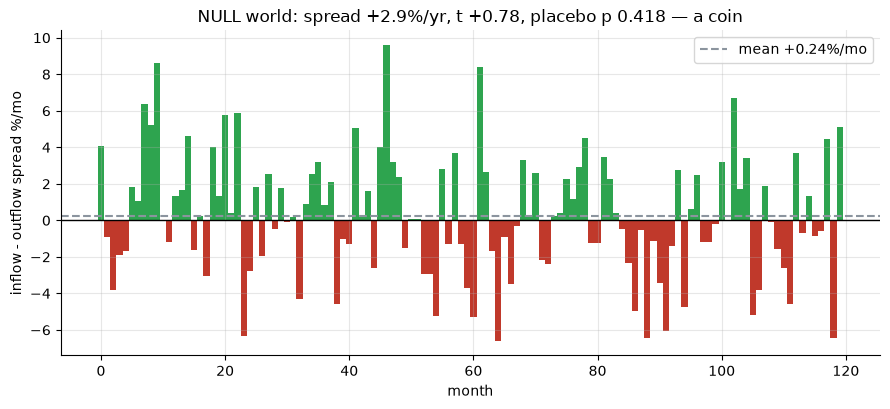

NULL: ann +2.88% | t +0.78 | hit 51.7% | placebo p 0.418


In [2]:
panel_null, _ = data.synthetic_panel(flow_alpha=0.0, seed=561)   # NO edge planted
s = st.spread_stats(panel_null, frac=0.33)
p = st.placebo_pvalue(panel_null, frac=0.33, n_perm=2000, seed=561)
series = st.monthly_spread_series(panel_null, frac=0.33)
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(series.index, series.values*100, color=[GREEN if v>0 else RED for v in series.values], width=1.0)
ax.axhline(0, c='k', lw=1); ax.axhline(s['mean_m']*100, c=GREY, ls='--', lw=1.5, label=f"mean {s['mean_m']*100:+.2f}%/mo")
ax.set_xlabel('month'); ax.set_ylabel('inflow - outflow spread %/mo')
ax.set_title(f"NULL world: spread {s['ann']*100:+.1f}%/yr, t {s['t']:+.2f}, placebo p {p:.3f} — a coin")
ax.legend(); plt.tight_layout(); plt.show()
print(f"NULL: ann {s['ann']*100:+.2f}% | t {s['t']:+.2f} | hit {s['hit']*100:.1f}% | placebo p {p:.3f}")

There's the honest baseline. With no real edge, the flow spread wobbles around zero: **+2.88%/yr**, *t* **+0.78**, it wins only **51.7%** of months, and the shuffle test *p* = **0.418** (about a coin). This is what 'chasing flows does nothing' looks like — and with no real tape, we can't rule out that the real world is exactly this.

**But wait — could a real edge exist and we'd just miss it?** No. Watch: plant a small, realistic flow-momentum edge and re-run the same sort.

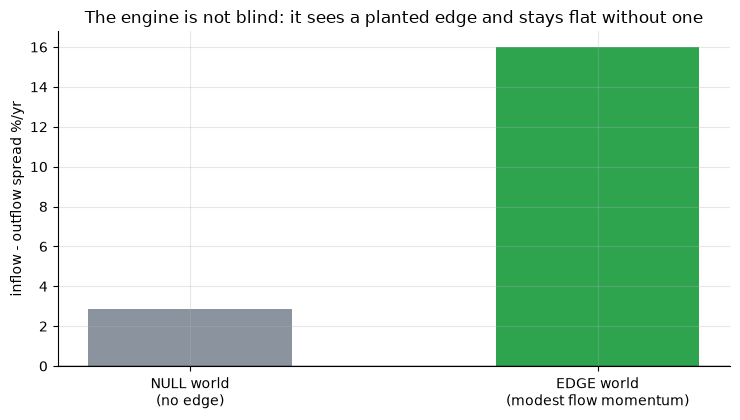

null +2.9%/yr (t +0.78)  vs  edge +16.0%/yr (t +4.35)


In [3]:
panel_edge, _ = data.synthetic_panel(flow_alpha=0.005, seed=561)  # modest edge planted
s_null = st.spread_stats(panel_null, 0.33); s_edge = st.spread_stats(panel_edge, 0.33)
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(['NULL world\n(no edge)', 'EDGE world\n(modest flow momentum)'],
       [s_null['ann']*100, s_edge['ann']*100], color=[GREY, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('inflow - outflow spread %/yr')
ax.set_title('The engine is not blind: it sees a planted edge and stays flat without one')
plt.tight_layout(); plt.show()
print(f"null {s_null['ann']*100:+.1f}%/yr (t {s_null['t']:+.2f})  vs  edge {s_edge['ann']*100:+.1f}%/yr (t {s_edge['t']:+.2f})")

So the detector works: a planted edge shows up loud (**+15.99%/yr**, *t* **+4.35**), the null stays flat. The reason we still say `Weak`, not `Real`, is **not** a broken engine — it's that we have **no real ETF-flow tape** to point it at, and the literature can't even agree on the sign.

## 5 · The verdict

- **Signal — Weak.** The claim has genuine academic support, but it fights an equally documented *reversal* (crowding) effect, and there is **no free real tape** to certify it. On the honest null the spread is a coin. Synthetic-only ⇒ capped below `Real`.
- **Tradability — Mirage.** You can't cheaply *measure* ETF flows on a retail stack, so there is nothing to trade — regardless of which sign the truth turns out to be.

## 6 · Could you actually trade it?

Not on free data. The whole trade hinges on a clean daily *shares-outstanding* series to compute flows — a paid vendor field. And even if you bought that feed, you'd be betting on a signal whose *sign* the academic literature can't agree on: flow persistence vs. crowding reversal. ETFs themselves are cheap and liquid (in our planted world, costs barely dent it: **+15.99%** gross → **+14.15%** net) — but cheap frictions don't help when you can't measure the signal in the first place. `Mirage`.

## 7 · Going further 🚪

- **The control (beat 7 of the quant notebook).** We plant the edge at *both* signs — momentum **and** the reversal trap — and the engine catches each, staying flat at zero. Proof it's the *data* that's missing, not the test.
- **The real test needs the paid feed.** Re-run this with a genuine daily shares-outstanding panel (Bloomberg / issuer files) across a full cycle, and settle the sign dispute on the tape.
- **Cousins on the desk.** [378 ETF-NAV-Premium](../../378-etf-nav-premium/) trades the ETF *price-vs-NAV* gap; [507](../../507-cross-sectional-momentum/) and [518](../../518-time-series-momentum/) trade *return* momentum. This one is about **flow**.

*Think flow momentum is real (or a real trap)? Fork this, wire in a paid daily shares-outstanding feed, and show the inflow-minus-outflow spread clearing t = 2 — in *either* direction — on the real tape.*